## imports

In [ ]:
import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn scipy gensim pyLDAvis textblob spacy wordcloud networkx plotly nltk streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 63.8 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

#Exp 1
##Content Analysis (Topic Modelling – LDA)

Content analysis: Analyze the content of social media data to determine what topics are being given data set using topic modelling

In [ ]:
pd?

In [ ]:
help(pd)

NameError: name 'pd' is not defined

In [ ]:
# Load your dataset
df = pd.read_csv('/content/sample_data/youtube_cleaned_extended_data_with_location.csv')

In [ ]:
df.head(5)

,video_id,title,description,channel_title,channel_id,published_at,upload_year,upload_month,view_count,like_count,...,engagement_rate,duration,category_id,thumbnail_url,tags,hashtags,emoji_list,emoji_count,title_length,country
0,ObqHKHoSE5Y,Samsung S26 Ultra Hands on - The Disappearing ...,My hands on with Samsung's Galaxy S26 Ultra!\n...,Mrwhosetheboss,UCMiJRAwDNSNzuYeN2uWa0pA,2026-02-25 18:00:00+00:00,2026,2,297487,28451,...,0.1041,PT14M17S,28,https://i.ytimg.com/vi/ObqHKHoSE5Y/hqdefault.jpg,"['samsung', 'galaxy', 's26', 's26 ultra', 's26...",[],['😁'],1,54,GB
1,PpIJSYXF7bg,iQOO 15R Unboxing & Test - The Flagship Killer...,Dosto aaj hum kar rahe hain iQOO 15R Unboxing ...,Technology Gyan,UC1tVU8H153ZFO9eRsxdJlhA,2026-02-24 07:31:28+00:00,2026,2,257730,16403,...,0.0673,PT14M57S,28,https://i.ytimg.com/vi/PpIJSYXF7bg/hqdefault.jpg,"['iQOO 15R Unboxing', 'iQOO 15R unboxing & fir...","['#Collab', '#iQOO15R', '#AmazonSpecials']","['✅', '✅', '✅', '✅', '🔥', '✅', '✅', '✅', '✅', ...",12,66,IN
2,gkklrVa8amY,The Most Futuristic Tech Of 2025.....,Dive into the future with us at MWC Barcelona!...,TechWiser,UCdp6GUwjKscp5ST4M4WgIpw,2025-03-06 10:09:46+00:00,2025,3,1028917,63276,...,0.0617,PT2M1S,28,https://i.ytimg.com/vi/gkklrVa8amY/hqdefault.jpg,['TechWiser'],[],[],0,37,IN
3,_KIzFIgzuYQ,China’s Street Tech Looks Like 2050 🚀,This invention from China proves they're livin...,TimeSaverShorts,UCBBmnOA_o5gYcYDScyt-ZTg,2025-08-20 19:00:37+00:00,2025,8,440029,6225,...,0.0145,PT16S,22,https://i.ytimg.com/vi/_KIzFIgzuYQ/hqdefault.jpg,[],"['#technology', '#innovation', '#china']",['🚀'],1,37,TR
4,KArch4rjU_0,USB in USB #charger #technology #electronic #f...,Maybe stop plugging things into each other to ...,ElectroBOOM,UCJ0-OtVpF0wOKEqT2Z1HEtA,2024-05-12 17:37:14+00:00,2024,5,47225912,2133136,...,0.0453,PT17S,28,https://i.ytimg.com/vi/KArch4rjU_0/hqdefault.jpg,[],"['#charger', '#technology', '#electronic', '#f...",[],0,50,CA


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   video_id         200 non-null    object 
 1   title            200 non-null    object 
 2   description      159 non-null    object 
 3   channel_title    200 non-null    object 
 4   channel_id       200 non-null    object 
 5   published_at     200 non-null    object 
 6   upload_year      200 non-null    int64  
 7   upload_month     200 non-null    int64  
 8   view_count       200 non-null    int64  
 9   like_count       200 non-null    int64  
 10  comment_count    200 non-null    int64  
 11  engagement_rate  200 non-null    float64
 12  duration         200 non-null    object 
 13  category_id      200 non-null    int64  
 14  thumbnail_url    200 non-null    object 
 15  tags             200 non-null    object 
 16  hashtags         200 non-null    object 
 17  emoji_list      

In [ ]:
df.isnull().sum()

,0
video_id,0
title,0
description,41
channel_title,0
channel_id,0
published_at,0
upload_year,0
upload_month,0
view_count,0
like_count,0


## Using TFID Vector for stop words

In [ ]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim import corpora
from gensim.models import LdaModel

# Load data
df = pd.read_csv('/content/sample_data/youtube_cleaned_extended_data_with_location.csv')
texts_data = df['title'].dropna()

# 🔹 Step 1: Clean text (regex)
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

clean_texts = texts_data.apply(clean_text)

# 🔹 Step 2: TF-IDF (removes stopwords automatically)
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(clean_texts)

# 🔹 Step 3: Convert to tokens (for gensim)
tokens = [text.split() for text in clean_texts]

# 🔹 Step 4: Dictionary & Corpus
dictionary = corpora.Dictionary(tokens)
corpus = [dictionary.doc2bow(text) for text in tokens]

# 🔹 Step 5: LDA
lda = LdaModel(corpus, num_topics=3, id2word=dictionary, passes=10)

# 🔹 Step 6: Print Topics
for i, topic in lda.print_topics():
    print(f"Topic {i}: {topic}")

In [ ]:
pip install pyLDAvis

### visualisation

In [ ]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

vis = gensimvis.prepare(lda, corpus, dictionary)

# Save file
pyLDAvis.save_html(vis, 'lda_vis.html')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# OR Using Gensim for stop words removal

In [ ]:
import pandas as pd
import re
from gensim.parsing.preprocessing import remove_stopwords
from gensim import corpora
from gensim.models import LdaModel

# Load data
df = pd.read_csv('/content/sample_data/youtube_cleaned_extended_data_with_location.csv')
texts_data = df['title'].dropna()

# 🔹 Preprocess
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)   # regex cleaning
    text = remove_stopwords(text)            # remove stopwords (gensim)
    tokens = text.split()                    # tokenize
    return tokens

texts = texts_data.apply(preprocess)

# 🔹 Dictionary & Corpus
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# 🔹 LDA
lda = LdaModel(corpus, num_topics=3, id2word=dictionary, passes=10)

# 🔹 Topics
for i, topic in lda.print_topics():
    print(f"Topic {i}: {topic}")

# Exp 2
## Location Analysis

Location analysis: Analyze the location data associated with tweets to understand where particular location are most prevalent.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Load dataset
df = pd.read_csv('/content/sample_data/youtube_cleaned_extended_data_with_location.csv')

In [ ]:
# Check column names (important)
print(df.columns)

Index(['video_id', 'title', 'description', 'channel_title', 'channel_id',
       'published_at', 'upload_year', 'upload_month', 'view_count',
       'like_count', 'comment_count', 'engagement_rate', 'duration',
       'category_id', 'thumbnail_url', 'tags', 'hashtags', 'emoji_list',
       'emoji_count', 'title_length', 'country'],
      dtype='object')


In [ ]:
df.isnull().sum()

,0
video_id,0
title,0
description,41
channel_title,0
channel_id,0
published_at,0
upload_year,0
upload_month,0
view_count,0
like_count,0


In [ ]:
# Assuming column is 'location'
location_count = df['country'].dropna().value_counts()


In [ ]:
# Print top locations
print(location_count.head(10))

country
IN         82
US         47
Unknown    23
GB         22
CA          8
BD          3
PK          3
AU          2
TR          2
SE          1
Name: count, dtype: int64


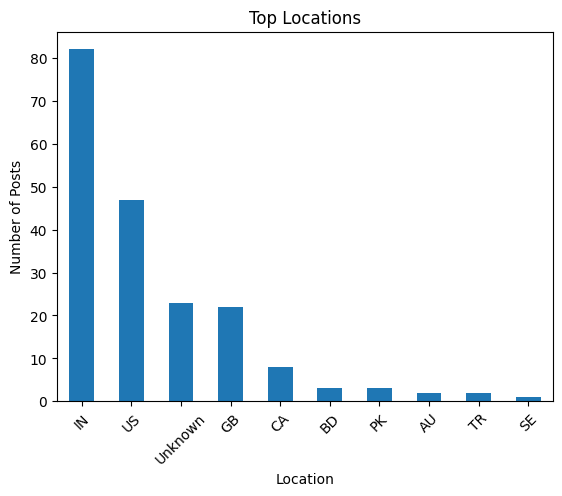

In [ ]:
# Plot
location_count.head(10).plot(kind='bar')
plt.title("Top Locations")
plt.xlabel("Location")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.show()

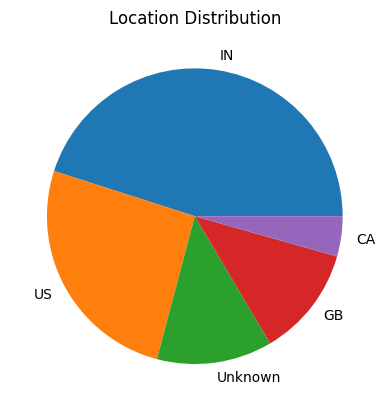

In [ ]:
top5 = location_count.head(5)

top5.plot(kind='pie', autopct='%1.1f%%')
plt.title("Location Distribution")
plt.ylabel("")
plt.show()

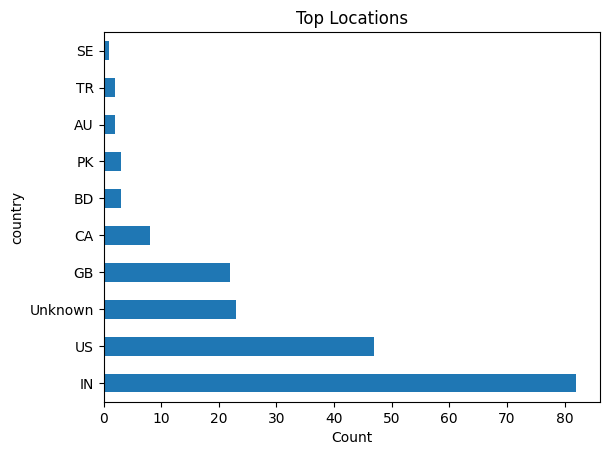

In [ ]:
location_count.head(10).plot(kind='barh')
plt.title("Top Locations")
plt.xlabel("Count")
plt.show()

# Location Analysis using NER

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
import spacy

# Load model
nlp = spacy.load("en_core_web_sm")

# Load dataset
df = pd.read_csv('/content/sample_data/youtube_cleaned_extended_data_with_location.csv')

# Function to extract locations
def extract_location(text):
    doc = nlp(str(text))
    return [ent.text for ent in doc.ents if ent.label_ == "GPE"]

# Apply on title
df['ner_location'] = df['title'].apply(extract_location)

print(df[['title', 'ner_location']].head())

                                               title ner_location
0  Samsung S26 Ultra Hands on - The Disappearing ...           []
1  iQOO 15R Unboxing & Test - The Flagship Killer...           []
2              The Most Futuristic Tech Of 2025.....           []
3              China’s Street Tech Looks Like 2050 🚀      [China]
4  USB in USB #charger #technology #electronic #f...           []


In [ ]:
from collections import Counter

all_locations = [loc for sublist in df['ner_location'] for loc in sublist]

count = Counter(all_locations)

print(count.most_common(10))

[('China', 16), ('Japan', 4), ('china', 2), ('South Korea', 1), ('USA', 1), ('TECHNOLOGIA', 1), ('Coolest Tech', 1), ('Bangladesh', 1)]


In [ ]:
all_locations.remove('TECHNOLOGIA')

In [ ]:
all_locations

['China',
 'China',
 'china',
 'China',
 'China',
 'South Korea',
 'China',
 'China',
 'China',
 'China',
 'China',
 'China',
 'China',
 'Japan',
 'China',
 'Japan',
 'China',
 'USA',
 'Japan',
 'China',
 'china',
 'China',
 'China',
 'Coolest Tech',
 'Japan',
 'Bangladesh']

In [ ]:
count = Counter(all_locations)

print(count.most_common(10))

[('China', 16), ('Japan', 4), ('china', 2), ('South Korea', 1), ('USA', 1), ('Coolest Tech', 1), ('Bangladesh', 1)]


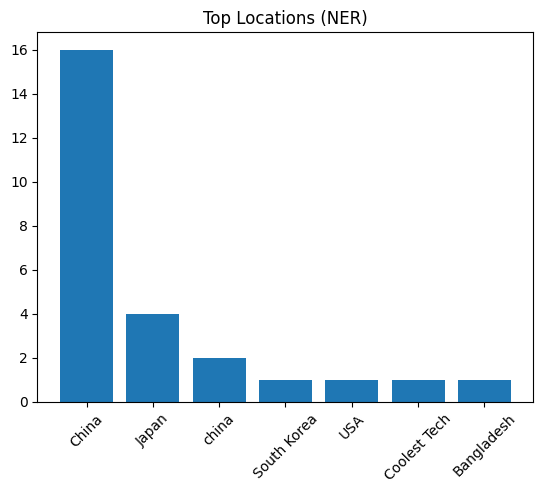

In [ ]:
import matplotlib.pyplot as plt

top = count.most_common(10)

labels = [x[0] for x in top]
values = [x[1] for x in top]

plt.bar(labels, values)
plt.title("Top Locations (NER)")
plt.xticks(rotation=45)
plt.show()

# Exp 3
## Trend Analysis (Time-based)

Trend analysis : Analyze the time data associated with social media and analyse its trends.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load dataset
df = pd.read_csv('/content/sample_data/youtube_cleaned_extended_data_with_location.csv')

In [ ]:
# Check columns (important)
print(df.columns)


Index(['video_id', 'title', 'description', 'channel_title', 'channel_id',
       'published_at', 'upload_year', 'upload_month', 'view_count',
       'like_count', 'comment_count', 'engagement_rate', 'duration',
       'category_id', 'thumbnail_url', 'tags', 'hashtags', 'emoji_list',
       'emoji_count', 'title_length', 'country'],
      dtype='object')


In [ ]:
df.head(5)

,video_id,title,description,channel_title,channel_id,published_at,upload_year,upload_month,view_count,like_count,...,engagement_rate,duration,category_id,thumbnail_url,tags,hashtags,emoji_list,emoji_count,title_length,country
0,ObqHKHoSE5Y,Samsung S26 Ultra Hands on - The Disappearing ...,My hands on with Samsung's Galaxy S26 Ultra!\n...,Mrwhosetheboss,UCMiJRAwDNSNzuYeN2uWa0pA,2026-02-25 18:00:00+00:00,2026,2,297487,28451,...,0.1041,PT14M17S,28,https://i.ytimg.com/vi/ObqHKHoSE5Y/hqdefault.jpg,"['samsung', 'galaxy', 's26', 's26 ultra', 's26...",[],['😁'],1,54,GB
1,PpIJSYXF7bg,iQOO 15R Unboxing & Test - The Flagship Killer...,Dosto aaj hum kar rahe hain iQOO 15R Unboxing ...,Technology Gyan,UC1tVU8H153ZFO9eRsxdJlhA,2026-02-24 07:31:28+00:00,2026,2,257730,16403,...,0.0673,PT14M57S,28,https://i.ytimg.com/vi/PpIJSYXF7bg/hqdefault.jpg,"['iQOO 15R Unboxing', 'iQOO 15R unboxing & fir...","['#Collab', '#iQOO15R', '#AmazonSpecials']","['✅', '✅', '✅', '✅', '🔥', '✅', '✅', '✅', '✅', ...",12,66,IN
2,gkklrVa8amY,The Most Futuristic Tech Of 2025.....,Dive into the future with us at MWC Barcelona!...,TechWiser,UCdp6GUwjKscp5ST4M4WgIpw,2025-03-06 10:09:46+00:00,2025,3,1028917,63276,...,0.0617,PT2M1S,28,https://i.ytimg.com/vi/gkklrVa8amY/hqdefault.jpg,['TechWiser'],[],[],0,37,IN
3,_KIzFIgzuYQ,China’s Street Tech Looks Like 2050 🚀,This invention from China proves they're livin...,TimeSaverShorts,UCBBmnOA_o5gYcYDScyt-ZTg,2025-08-20 19:00:37+00:00,2025,8,440029,6225,...,0.0145,PT16S,22,https://i.ytimg.com/vi/_KIzFIgzuYQ/hqdefault.jpg,[],"['#technology', '#innovation', '#china']",['🚀'],1,37,TR
4,KArch4rjU_0,USB in USB #charger #technology #electronic #f...,Maybe stop plugging things into each other to ...,ElectroBOOM,UCJ0-OtVpF0wOKEqT2Z1HEtA,2024-05-12 17:37:14+00:00,2024,5,47225912,2133136,...,0.0453,PT17S,28,https://i.ytimg.com/vi/KArch4rjU_0/hqdefault.jpg,[],"['#charger', '#technology', '#electronic', '#f...",[],0,50,CA


In [ ]:
# Assuming column is 'publishedAt' or 'date'
df['published_at'] = pd.to_datetime(df['published_at'], errors='coerce')

In [ ]:
# Group by date
trend = df.groupby(df['published_at'].dt.date).size()

In [ ]:

# Print data
print(trend.head())

published_at
2018-07-31    1
2021-06-27    1
2021-09-04    1
2021-10-18    1
2021-11-14    1
dtype: int64


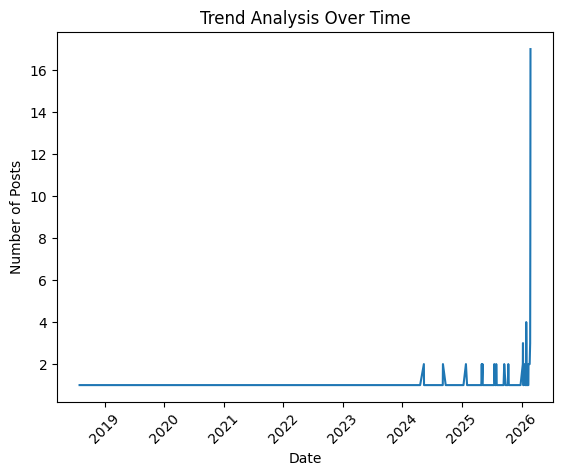

In [ ]:
# Plot trend
trend.plot()
plt.title("Trend Analysis Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.show()

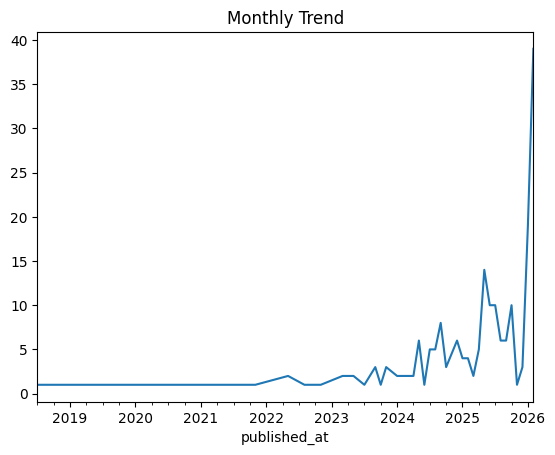

In [ ]:
monthly_trend = df.groupby(df['published_at'].dt.to_period('M')).size()

monthly_trend.plot()
plt.title("Monthly Trend")
plt.show()

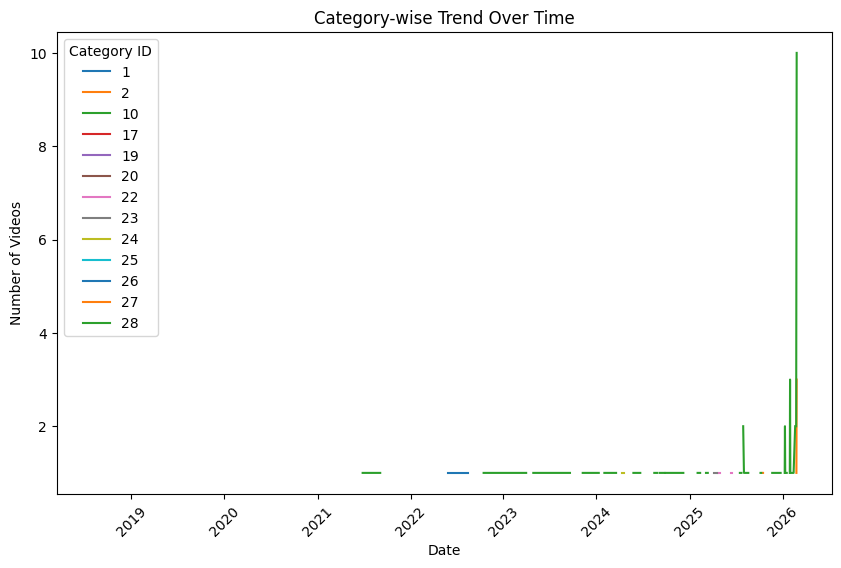

In [ ]:
# Group by date and category
trend = df.groupby([df['published_at'].dt.date, 'category_id']).size().unstack()

# Plot
trend.plot(figsize=(10,6))

plt.title("Category-wise Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Videos")
plt.xticks(rotation=45)
plt.legend(title="Category ID")
plt.show()

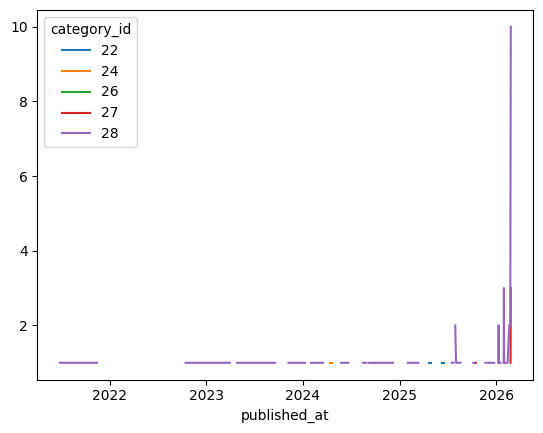

In [ ]:
top_cat = df['category_id'].value_counts().head(5).index
df_filtered = df[df['category_id'].isin(top_cat)]

trend = df_filtered.groupby([df_filtered['published_at'].dt.date, 'category_id']).size().unstack()
trend.plot()
plt.show()

# Exp 4
## Hashtag Popularity

Hashtag popularity analysis: Determine which hashtags are most popular among different user groups.

In [ ]:
import pandas as pd
import re
from collections import Counter

In [ ]:
# Load dataset
df = pd.read_csv('/content/sample_data/youtube_cleaned_extended_data_with_location.csv')

In [ ]:
df.head(5)

,video_id,title,description,channel_title,channel_id,published_at,upload_year,upload_month,view_count,like_count,...,engagement_rate,duration,category_id,thumbnail_url,tags,hashtags,emoji_list,emoji_count,title_length,country
0,ObqHKHoSE5Y,Samsung S26 Ultra Hands on - The Disappearing ...,My hands on with Samsung's Galaxy S26 Ultra!\n...,Mrwhosetheboss,UCMiJRAwDNSNzuYeN2uWa0pA,2026-02-25 18:00:00+00:00,2026,2,297487,28451,...,0.1041,PT14M17S,28,https://i.ytimg.com/vi/ObqHKHoSE5Y/hqdefault.jpg,"['samsung', 'galaxy', 's26', 's26 ultra', 's26...",[],['😁'],1,54,GB
1,PpIJSYXF7bg,iQOO 15R Unboxing & Test - The Flagship Killer...,Dosto aaj hum kar rahe hain iQOO 15R Unboxing ...,Technology Gyan,UC1tVU8H153ZFO9eRsxdJlhA,2026-02-24 07:31:28+00:00,2026,2,257730,16403,...,0.0673,PT14M57S,28,https://i.ytimg.com/vi/PpIJSYXF7bg/hqdefault.jpg,"['iQOO 15R Unboxing', 'iQOO 15R unboxing & fir...",[],"['✅', '✅', '✅', '✅', '🔥', '✅', '✅', '✅', '✅', ...",12,66,IN
2,gkklrVa8amY,The Most Futuristic Tech Of 2025.....,Dive into the future with us at MWC Barcelona!...,TechWiser,UCdp6GUwjKscp5ST4M4WgIpw,2025-03-06 10:09:46+00:00,2025,3,1028917,63276,...,0.0617,PT2M1S,28,https://i.ytimg.com/vi/gkklrVa8amY/hqdefault.jpg,['TechWiser'],[],[],0,37,IN
3,_KIzFIgzuYQ,China’s Street Tech Looks Like 2050 🚀,This invention from China proves they're livin...,TimeSaverShorts,UCBBmnOA_o5gYcYDScyt-ZTg,2025-08-20 19:00:37+00:00,2025,8,440029,6225,...,0.0145,PT16S,22,https://i.ytimg.com/vi/_KIzFIgzuYQ/hqdefault.jpg,[],[],['🚀'],1,37,TR
4,KArch4rjU_0,USB in USB #charger #technology #electronic #f...,Maybe stop plugging things into each other to ...,ElectroBOOM,UCJ0-OtVpF0wOKEqT2Z1HEtA,2024-05-12 17:37:14+00:00,2024,5,47225912,2133136,...,0.0453,PT17S,28,https://i.ytimg.com/vi/KArch4rjU_0/hqdefault.jpg,[],"[#charger, #technology, #electronic, #funny]",[],0,50,CA


In [ ]:
df.isnull().sum()

,0
video_id,0
title,0
description,41
channel_title,0
channel_id,0
published_at,0
upload_year,0
upload_month,0
view_count,0
like_count,0


In [ ]:
# Extract hashtags from title
def extract_hashtags(text):
    return re.findall(r"#\w+", str(text).lower())

In [ ]:
df['hashtags'] = df['title'].apply(extract_hashtags)

In [ ]:
# Flatten list
all_tags = [tag for sublist in df['hashtags'] for tag in sublist]

In [ ]:
# Count hashtags
count = Counter(all_tags)

In [ ]:
# Top hashtags
top_hashtags = count.most_common(10)

print(top_hashtags)

[('#technology', 60), ('#shorts', 45), ('#tech', 33), ('#trending', 17), ('#science', 9), ('#viral', 7), ('#pc', 6), ('#ytshorts', 6), ('#youtubeshorts', 6), ('#funny', 5)]


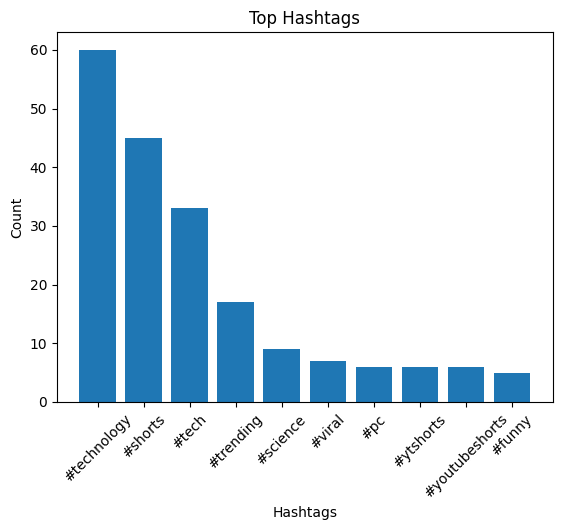

In [ ]:
import matplotlib.pyplot as plt

tags = [tag[0] for tag in top_hashtags]
values = [tag[1] for tag in top_hashtags]

plt.bar(tags, values)
plt.title("Top Hashtags")
plt.xlabel("Hashtags")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
grouped = df.explode('hashtags')

group_analysis = grouped.groupby(['category_id', 'hashtags']).size()

print(group_analysis.head())

category_id  hashtags   
1            #shorts        1
2            #automobile    1
             #car           1
             #engineer      1
             #tech          1
dtype: int64


# Exp 5
## Sentiment Analysis

Sentiment Analysis /topic analysis / keyword analysis for given dataset

In [ ]:
import pandas as pd
from textblob import TextBlob

In [ ]:
# Load dataset
df = pd.read_csv('/content/sample_data/youtube_cleaned_extended_data_with_location.csv')

In [ ]:
# Function to get sentiment
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

In [ ]:
# Apply on title
df['sentiment'] = df['title'].apply(get_sentiment)

In [ ]:
# Classify sentiment
def label(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

In [ ]:
df['sentiment_label'] = df['sentiment'].apply(label)

# Count
print(df['sentiment_label'].value_counts())

sentiment_label
Neutral     113
Positive     69
Negative     18
Name: count, dtype: int64


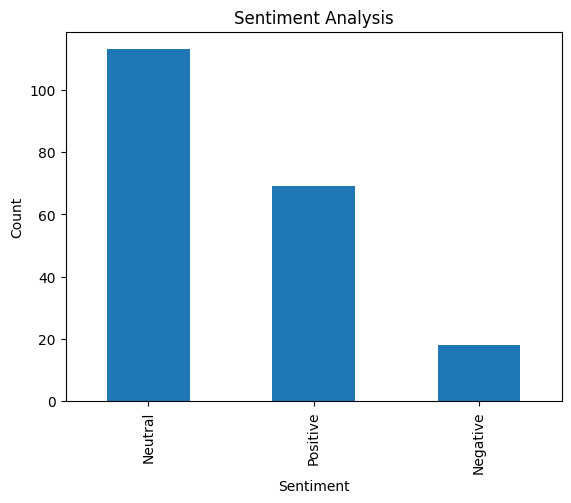

In [ ]:
import matplotlib.pyplot as plt

df['sentiment_label'].value_counts().plot(kind='bar')

plt.title("Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Keyword Analysis

In [ ]:
from collections import Counter
import pandas as pd

df = pd.read_csv('/content/sample_data/youtube_cleaned_extended_data_with_location.csv')

words = " ".join(df['title'].dropna()).lower().split()

count = Counter(words)

print(count.most_common(10))

[('#technology', 58), ('technology', 51), ('#shorts', 43), ('tech', 39), ('#tech', 33), ('the', 30), ('|', 22), ('#trending', 16), ('i', 15), ('in', 13)]


WordCloud

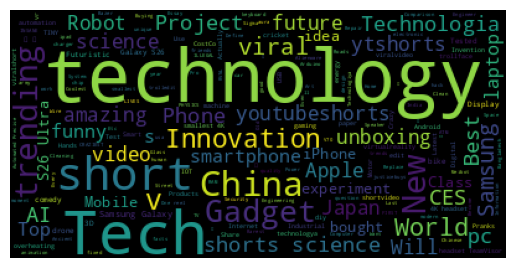

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['title'].dropna())

wc = WordCloud().generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

# Exp 6
## User engagement analysis

User engagement analysis: analyze how users engage with content for given social media data to understand what types of content are most engaging

In [ ]:
import pandas as pd

df = pd.read_csv('/content/sample_data/youtube_cleaned_extended_data_with_location.csv')

In [ ]:
df.head(5)

,video_id,title,description,channel_title,channel_id,published_at,upload_year,upload_month,view_count,like_count,...,engagement_rate,duration,category_id,thumbnail_url,tags,hashtags,emoji_list,emoji_count,title_length,country
0,ObqHKHoSE5Y,Samsung S26 Ultra Hands on - The Disappearing ...,My hands on with Samsung's Galaxy S26 Ultra!\n...,Mrwhosetheboss,UCMiJRAwDNSNzuYeN2uWa0pA,2026-02-25 18:00:00+00:00,2026,2,297487,28451,...,0.1041,PT14M17S,28,https://i.ytimg.com/vi/ObqHKHoSE5Y/hqdefault.jpg,"['samsung', 'galaxy', 's26', 's26 ultra', 's26...",[],['😁'],1,54,GB
1,PpIJSYXF7bg,iQOO 15R Unboxing & Test - The Flagship Killer...,Dosto aaj hum kar rahe hain iQOO 15R Unboxing ...,Technology Gyan,UC1tVU8H153ZFO9eRsxdJlhA,2026-02-24 07:31:28+00:00,2026,2,257730,16403,...,0.0673,PT14M57S,28,https://i.ytimg.com/vi/PpIJSYXF7bg/hqdefault.jpg,"['iQOO 15R Unboxing', 'iQOO 15R unboxing & fir...","['#Collab', '#iQOO15R', '#AmazonSpecials']","['✅', '✅', '✅', '✅', '🔥', '✅', '✅', '✅', '✅', ...",12,66,IN
2,gkklrVa8amY,The Most Futuristic Tech Of 2025.....,Dive into the future with us at MWC Barcelona!...,TechWiser,UCdp6GUwjKscp5ST4M4WgIpw,2025-03-06 10:09:46+00:00,2025,3,1028917,63276,...,0.0617,PT2M1S,28,https://i.ytimg.com/vi/gkklrVa8amY/hqdefault.jpg,['TechWiser'],[],[],0,37,IN
3,_KIzFIgzuYQ,China’s Street Tech Looks Like 2050 🚀,This invention from China proves they're livin...,TimeSaverShorts,UCBBmnOA_o5gYcYDScyt-ZTg,2025-08-20 19:00:37+00:00,2025,8,440029,6225,...,0.0145,PT16S,22,https://i.ytimg.com/vi/_KIzFIgzuYQ/hqdefault.jpg,[],"['#technology', '#innovation', '#china']",['🚀'],1,37,TR
4,KArch4rjU_0,USB in USB #charger #technology #electronic #f...,Maybe stop plugging things into each other to ...,ElectroBOOM,UCJ0-OtVpF0wOKEqT2Z1HEtA,2024-05-12 17:37:14+00:00,2024,5,47225912,2133136,...,0.0453,PT17S,28,https://i.ytimg.com/vi/KArch4rjU_0/hqdefault.jpg,[],"['#charger', '#technology', '#electronic', '#f...",[],0,50,CA


In [ ]:
df.columns

Index(['video_id', 'title', 'description', 'channel_title', 'channel_id',
       'published_at', 'upload_year', 'upload_month', 'view_count',
       'like_count', 'comment_count', 'engagement_rate', 'duration',
       'category_id', 'thumbnail_url', 'tags', 'hashtags', 'emoji_list',
       'emoji_count', 'title_length', 'country'],
      dtype='object')

In [ ]:
# # Engagement = likes + comments (you can include views if needed)
# df['engagement'] = df['like_count'] + df['comment_count']

print(df[['title', 'engagement_rate']].head())

                                               title  engagement_rate
0  Samsung S26 Ultra Hands on - The Disappearing ...           0.1041
1  iQOO 15R Unboxing & Test - The Flagship Killer...           0.0673
2              The Most Futuristic Tech Of 2025.....           0.0617
3              China’s Street Tech Looks Like 2050 🚀           0.0145
4  USB in USB #charger #technology #electronic #f...           0.0453


In [ ]:
# Top Engaging Content
top = df.sort_values(by='engagement_rate', ascending=False)
print(top[['title', 'engagement_rate']].head(10))

                                                 title  engagement_rate
161  Samsung Galaxy S26: Fomos aos EUA conferir o l...           0.4178
9    The Samsung Galaxy S26 Ultra is Here! #tech #s...           0.3836
28        15 Cool Tech That Are Actually Worth Buying!           0.1095
0    Samsung S26 Ultra Hands on - The Disappearing ...           0.1041
10                   WE TRIED WORLD'S TOP 3 TECH HACKS           0.0952
68   You are being misled about renewable energy te...           0.0942
160    Tajna Technologia - Reprodukcja Pojazdów Obcych           0.0894
86   Modern Technology Has Become Unusable (And It'...           0.0843
178  Samsung Galaxy S26, S26+ ve S26 Ultra ön incel...           0.0822
166                 Technology - After “NANGNA THONGO”           0.0816


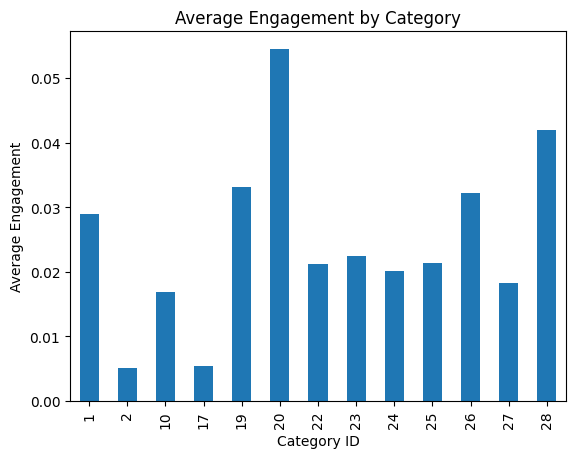

In [ ]:
# Engagement by Category
import matplotlib.pyplot as plt

engagement_category = df.groupby('category_id')['engagement_rate'].mean()

engagement_category.plot(kind='bar')

plt.title("Average Engagement by Category")
plt.xlabel("Category ID")
plt.ylabel("Average Engagement")
plt.show()

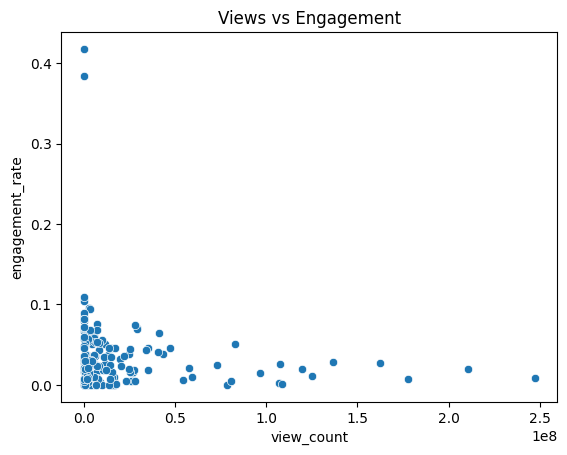

In [ ]:
# Engagement vs Views
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='view_count', y='engagement_rate', data=df)

plt.title("Views vs Engagement")
plt.show()

# Exp 7
## Exploratory Data Analysis (EDA)

Exploratory Data Analysis and visualization for given data set

In [ ]:
import pandas as pd

df = pd.read_csv('/content/sample_data/youtube_cleaned_extended_data_with_location.csv')

df.head()

,video_id,title,description,channel_title,channel_id,published_at,upload_year,upload_month,view_count,like_count,...,engagement_rate,duration,category_id,thumbnail_url,tags,hashtags,emoji_list,emoji_count,title_length,country
0,ObqHKHoSE5Y,Samsung S26 Ultra Hands on - The Disappearing ...,My hands on with Samsung's Galaxy S26 Ultra!\n...,Mrwhosetheboss,UCMiJRAwDNSNzuYeN2uWa0pA,2026-02-25 18:00:00+00:00,2026,2,297487,28451,...,0.1041,PT14M17S,28,https://i.ytimg.com/vi/ObqHKHoSE5Y/hqdefault.jpg,"['samsung', 'galaxy', 's26', 's26 ultra', 's26...",[],['😁'],1,54,GB
1,PpIJSYXF7bg,iQOO 15R Unboxing & Test - The Flagship Killer...,Dosto aaj hum kar rahe hain iQOO 15R Unboxing ...,Technology Gyan,UC1tVU8H153ZFO9eRsxdJlhA,2026-02-24 07:31:28+00:00,2026,2,257730,16403,...,0.0673,PT14M57S,28,https://i.ytimg.com/vi/PpIJSYXF7bg/hqdefault.jpg,"['iQOO 15R Unboxing', 'iQOO 15R unboxing & fir...","['#Collab', '#iQOO15R', '#AmazonSpecials']","['✅', '✅', '✅', '✅', '🔥', '✅', '✅', '✅', '✅', ...",12,66,IN
2,gkklrVa8amY,The Most Futuristic Tech Of 2025.....,Dive into the future with us at MWC Barcelona!...,TechWiser,UCdp6GUwjKscp5ST4M4WgIpw,2025-03-06 10:09:46+00:00,2025,3,1028917,63276,...,0.0617,PT2M1S,28,https://i.ytimg.com/vi/gkklrVa8amY/hqdefault.jpg,['TechWiser'],[],[],0,37,IN
3,_KIzFIgzuYQ,China’s Street Tech Looks Like 2050 🚀,This invention from China proves they're livin...,TimeSaverShorts,UCBBmnOA_o5gYcYDScyt-ZTg,2025-08-20 19:00:37+00:00,2025,8,440029,6225,...,0.0145,PT16S,22,https://i.ytimg.com/vi/_KIzFIgzuYQ/hqdefault.jpg,[],"['#technology', '#innovation', '#china']",['🚀'],1,37,TR
4,KArch4rjU_0,USB in USB #charger #technology #electronic #f...,Maybe stop plugging things into each other to ...,ElectroBOOM,UCJ0-OtVpF0wOKEqT2Z1HEtA,2024-05-12 17:37:14+00:00,2024,5,47225912,2133136,...,0.0453,PT17S,28,https://i.ytimg.com/vi/KArch4rjU_0/hqdefault.jpg,[],"['#charger', '#technology', '#electronic', '#f...",[],0,50,CA


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   video_id         200 non-null    object 
 1   title            200 non-null    object 
 2   description      159 non-null    object 
 3   channel_title    200 non-null    object 
 4   channel_id       200 non-null    object 
 5   published_at     200 non-null    object 
 6   upload_year      200 non-null    int64  
 7   upload_month     200 non-null    int64  
 8   view_count       200 non-null    int64  
 9   like_count       200 non-null    int64  
 10  comment_count    200 non-null    int64  
 11  engagement_rate  200 non-null    float64
 12  duration         200 non-null    object 
 13  category_id      200 non-null    int64  
 14  thumbnail_url    200 non-null    object 
 15  tags             200 non-null    object 
 16  hashtags         200 non-null    object 
 17  emoji_list      

In [ ]:
print(df.isnull().sum())

video_id            0
title               0
description        41
channel_title       0
channel_id          0
published_at        0
upload_year         0
upload_month        0
view_count          0
like_count          0
comment_count       0
engagement_rate     0
duration            0
category_id         0
thumbnail_url       0
tags                0
hashtags            0
emoji_list          0
emoji_count         0
title_length        0
country             0
dtype: int64


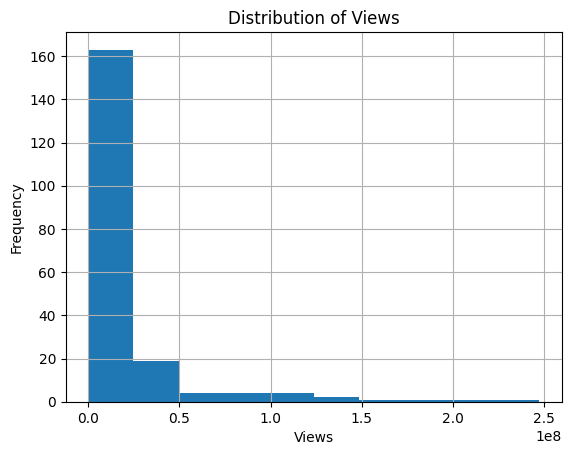

In [ ]:
import matplotlib.pyplot as plt

df['view_count'].hist()

plt.title("Distribution of Views")
plt.xlabel("Views")
plt.ylabel("Frequency")
plt.show()

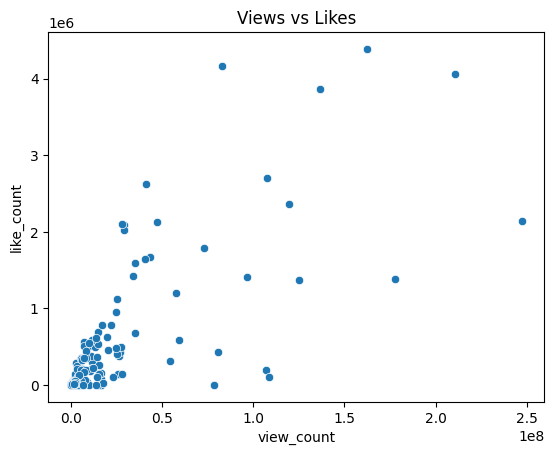

In [ ]:
import seaborn as sns

sns.scatterplot(x='view_count', y='like_count', data=df)

plt.title("Views vs Likes")
plt.show()

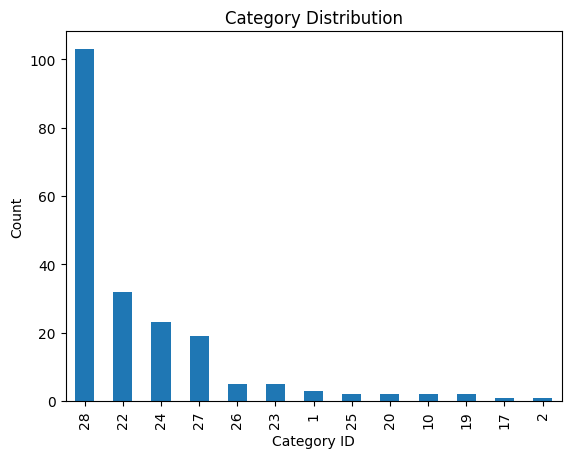

In [ ]:
df['category_id'].value_counts().plot(kind='bar')

plt.title("Category Distribution")
plt.xlabel("Category ID")
plt.ylabel("Count")
plt.show()

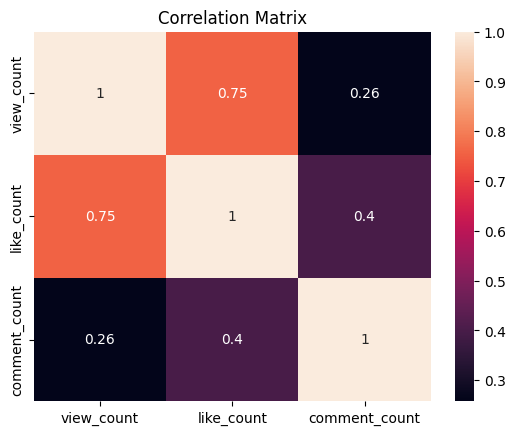

In [ ]:
import seaborn as sns

corr = df[['view_count', 'like_count', 'comment_count']].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")
plt.show()

# Exp 8
## Brand Analysis

Brand analysis: analyze the conversation around a particular brand for given dataset

In [ ]:
import pandas as pd

df = pd.read_csv('/content/sample_data/youtube_cleaned_extended_data_with_location.csv')

In [ ]:
brand = "samsung"

brand_data = df[df['title'].str.contains(brand, case=False, na=False)]

print("Total mentions:", len(brand_data))
print(brand_data[['title']].head())

Total mentions: 12
                                                title
0   Samsung S26 Ultra Hands on - The Disappearing ...
9   The Samsung Galaxy S26 Ultra is Here! #tech #s...
18  Samsung S22Ultra screen quality display. #Sams...
29  Samsung galaxy S24ultra titanium violet Displa...
44  Samsung Mobile Phones Mobile Phones Digital Te...


In [ ]:
brand_data['engagement_rate'] = brand_data['like_count'] + brand_data['comment_count']

print(brand_data['engagement_rate'].describe())

count    1.200000e+01
mean     1.349602e+05
std      3.972314e+05
min      0.000000e+00
25%      2.197500e+02
50%      6.517000e+03
75%      1.985975e+04
max      1.388894e+06
Name: engagement_rate, dtype: float64


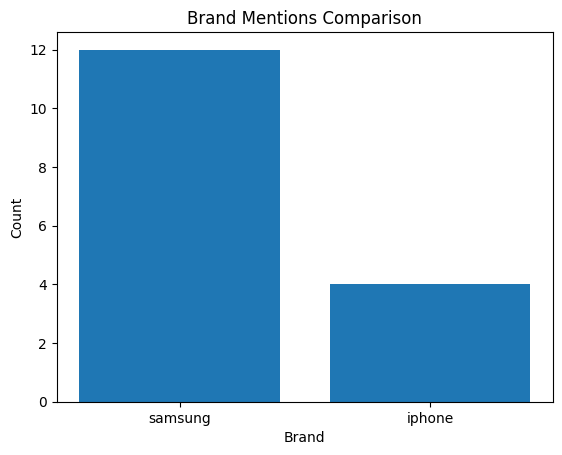

In [ ]:
import matplotlib.pyplot as plt

brands = ['samsung', 'iphone']

counts = [
    df['title'].str.contains(b, case=False, na=False).sum()
    for b in brands
]

plt.bar(brands, counts)
plt.title("Brand Mentions Comparison")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.show()

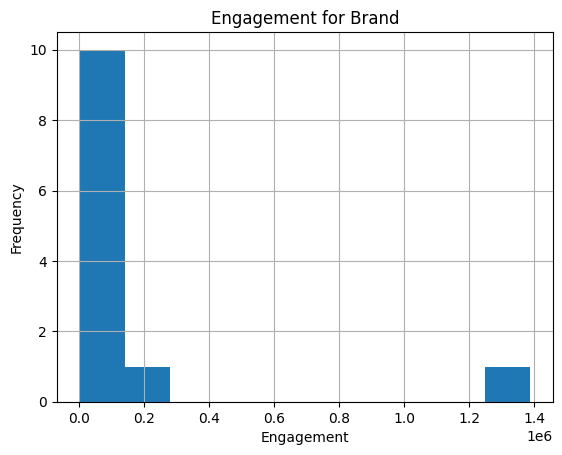

In [ ]:
brand_data['engagement_rate'].hist()

plt.title("Engagement for Brand")
plt.xlabel("Engagement")
plt.ylabel("Frequency")
plt.show()

# Exp 9
## Competitor Analysis

Analyze competitor activities using social media for given problem statement

In [ ]:
import pandas as pd

df = pd.read_csv('/content/sample_data/youtube_cleaned_extended_data_with_location.csv')

In [ ]:
brands = ['samsung', 'iphone', 'tesla']

In [ ]:
mentions = {}

for brand in brands:
    count = df['title'].str.contains(brand, case=False, na=False).sum()
    mentions[brand] = count

print(mentions)

{'samsung': np.int64(12), 'iphone': np.int64(4), 'tesla': np.int64(0)}


In [ ]:
engagement = {}

for brand in brands:
    data = df[df['title'].str.contains(brand, case=False, na=False)]
    engagement[brand] = (data['like_count'] + data['comment_count']).mean()

print(engagement)

{'samsung': np.float64(134960.16666666666), 'iphone': np.float64(20206.5), 'tesla': nan}


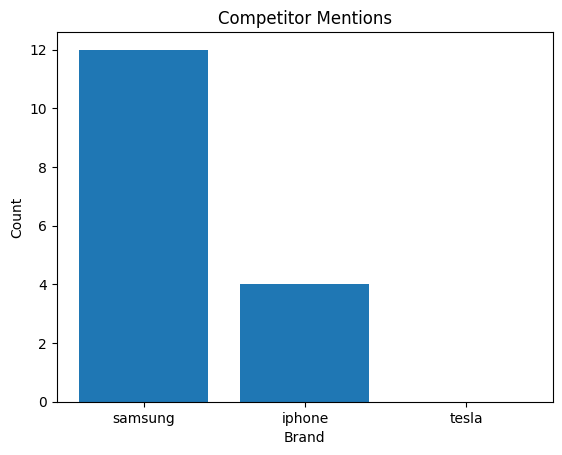

In [ ]:
import matplotlib.pyplot as plt

# Mentions Graph
plt.bar(mentions.keys(), mentions.values())
plt.title("Competitor Mentions")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.show()


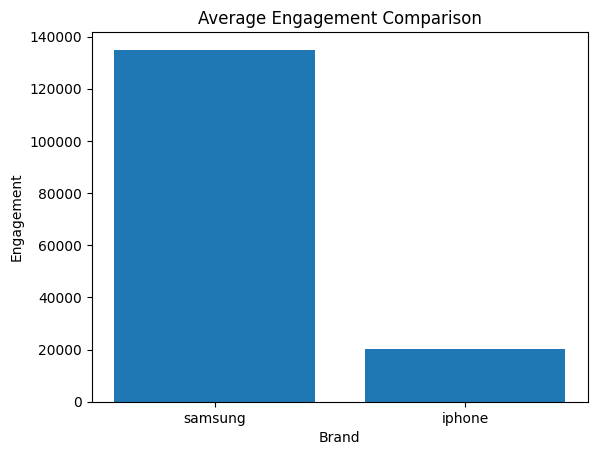

In [ ]:

# Engagement Graph
plt.bar(engagement.keys(), engagement.values())
plt.title("Average Engagement Comparison")
plt.xlabel("Brand")
plt.ylabel("Engagement")
plt.show()

# Exp 10
## Social Network Analysis
Social Network data analysis for community detection and influential analytics for given problem using Girvan newman algorithm

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import girvan_newman
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/content/sample_data/youtube_cleaned_extended_data_with_location.csv')

print(df.head())
print(df.info())

      video_id                                              title  \
0  ObqHKHoSE5Y  Samsung S26 Ultra Hands on - The Disappearing ...   
1  PpIJSYXF7bg  iQOO 15R Unboxing & Test - The Flagship Killer...   
2  gkklrVa8amY              The Most Futuristic Tech Of 2025.....   
3  _KIzFIgzuYQ              China’s Street Tech Looks Like 2050 🚀   
4  KArch4rjU_0  USB in USB #charger #technology #electronic #f...   

                                         description    channel_title  \
0  My hands on with Samsung's Galaxy S26 Ultra!\n...   Mrwhosetheboss   
1  Dosto aaj hum kar rahe hain iQOO 15R Unboxing ...  Technology Gyan   
2  Dive into the future with us at MWC Barcelona!...        TechWiser   
3  This invention from China proves they're livin...  TimeSaverShorts   
4  Maybe stop plugging things into each other to ...      ElectroBOOM   

                 channel_id               published_at  upload_year  \
0  UCMiJRAwDNSNzuYeN2uWa0pA  2026-02-25 18:00:00+00:00         2026   
1  U

K-Means Clustering


In [ ]:
X = df[['view_count', 'like_count', 'comment_count']].dropna()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=0)
X['cluster'] = kmeans.fit_predict(X_scaled)

print(X.head())

   view_count  like_count  comment_count  cluster
0      297487       28451           2526        2
1      257730       16403            942        2
2     1028917       63276            193        2
3      440029        6225            174        2
4    47225912     2133136           5858        1


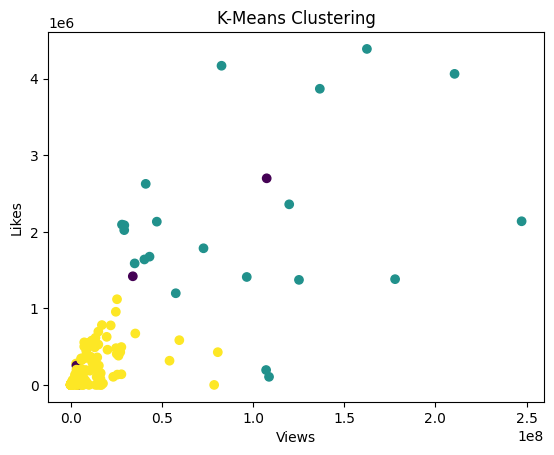

In [ ]:
plt.scatter(X['view_count'], X['like_count'], c=X['cluster'])

plt.xlabel("Views")
plt.ylabel("Likes")
plt.title("K-Means Clustering")
plt.show()

Cluster 0: Low engagement users  
Cluster 1: Medium engagement users  
Cluster 2: High engagement users  

# Ignore below , if u r doing kmeans

In [ ]:
if# Unique categories as nodes
categories = df['category_id'].dropna().unique()

G = nx.Graph()
G.add_nodes_from(categories)

# Connect categories in sequence (simple structure)
for i in range(len(categories)-1):
    G.add_edge(categories[i], categories[i+1])

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 13
Edges: 12


## Page rank

In [ ]:
pagerank = nx.pagerank(G)
print("Top nodes:", sorted(pagerank, key=pagerank.get, reverse=True)[:3])

Top nodes: [np.int64(22), np.int64(19), np.int64(24)]


## (Girvan-Newman)


In [ ]:
communities = next(girvan_newman(G))

for i, c in enumerate(communities):
    print(f"Community {i+1}:", list(c))

Community 1: [np.int64(22), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28)]
Community 2: [np.int64(1), np.int64(2), np.int64(10), np.int64(17), np.int64(19), np.int64(20), np.int64(23)]


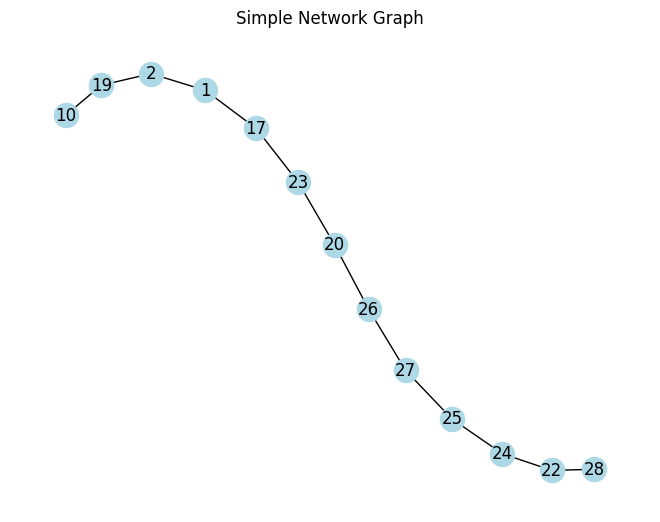

In [ ]:
nx.draw(G, with_labels=True, node_color='lightblue')
plt.title("Simple Network Graph")
plt.show()